In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
master_df = pd.read_csv('price_commo_2023_2026.csv', index_col=0)

In [41]:
master_df.index = pd.to_datetime(master_df.index)

In [42]:
master_df.columns

Index(['price', 'volume', 'london_temp', 'london_wind', 'london_clouds',
       'north_sea_wind', 'Scottish Highlands_wind', 'Cornwall_clouds',
       'oil_price', 'gas_price', 'hour', 'weekday', 'day_of_year'],
      dtype='object')

<Axes: ylabel='price'>

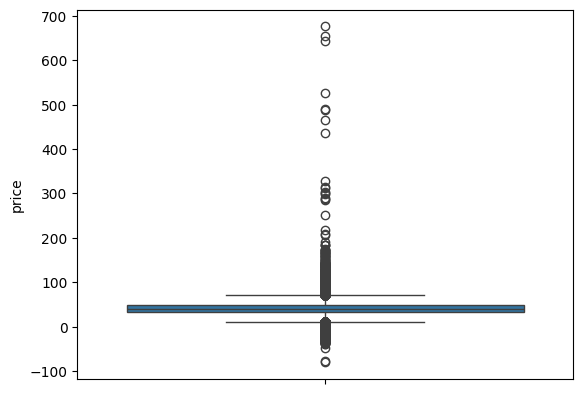

In [43]:
sns.boxplot(master_df['price'])

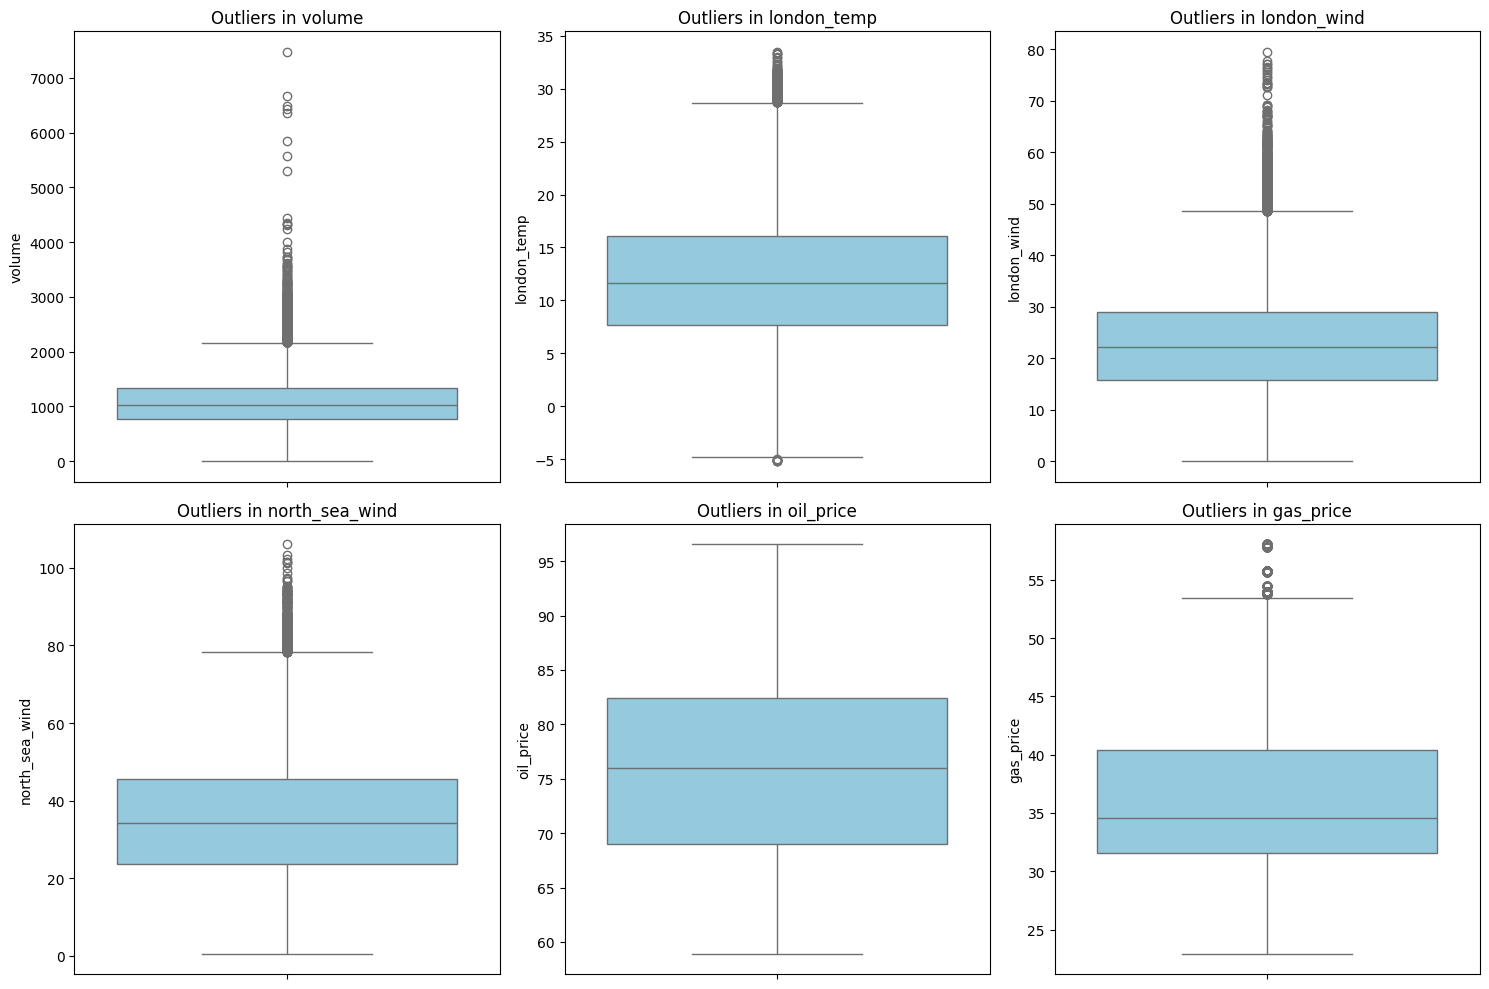

In [60]:
cols_to_check = ['volume', 'london_temp', 'london_wind', 'north_sea_wind', 'oil_price', 'gas_price']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=master_df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

In [45]:
Q1 = master_df['price'].quantile(0.25)
Q3 = master_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bridge = Q1 - (3 * IQR)
upper_bridge = Q3 + (6 * IQR)  # keep more high values

print(f"Lower Bound: {lower_bridge:.2f}")
print(f"Upper Bound: {upper_bridge:.2f}")

# Count how many outliers we have
outliers = master_df[(master_df['price'] < lower_bridge) | (master_df['price'] > upper_bridge)]
print(f"Total outliers identified: {len(outliers)} ({len(outliers)/len(master_df)*100:.2f}%)")

Lower Bound: -12.43
Upper Bound: 139.42
Total outliers identified: 229 (0.44%)


In [32]:
master_df['price'].describe()

count    52560.000000
mean        39.849083
std         18.407479
min        -80.555000
25%         33.125000
50%         40.540000
75%         48.310000
max        676.450000
Name: price, dtype: float64

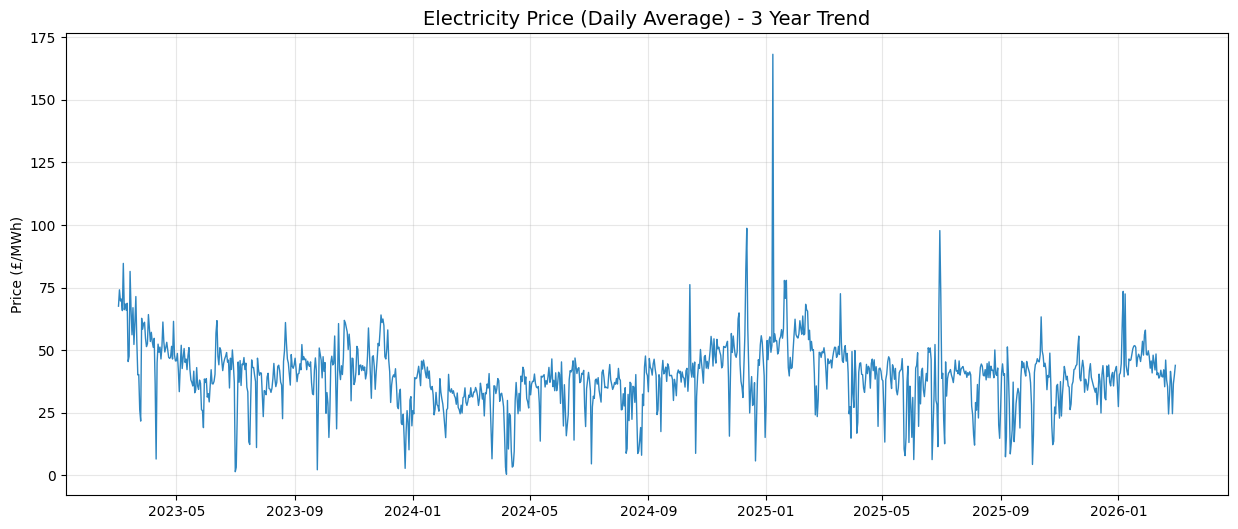

In [10]:
df_daily = master_df['price'].resample('D').mean()

plt.figure(figsize=(15, 6))
# Using a slightly thicker line since there are fewer points
plt.plot(df_daily.index, df_daily, color='#2E86C1', linewidth=1)

plt.title('Electricity Price (Daily Average) - 3 Year Trend', fontsize=14)
plt.ylabel('Price (£/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
master_df['price'] = master_df['price'].clip(lower=lower_bridge, upper=upper_bridge)

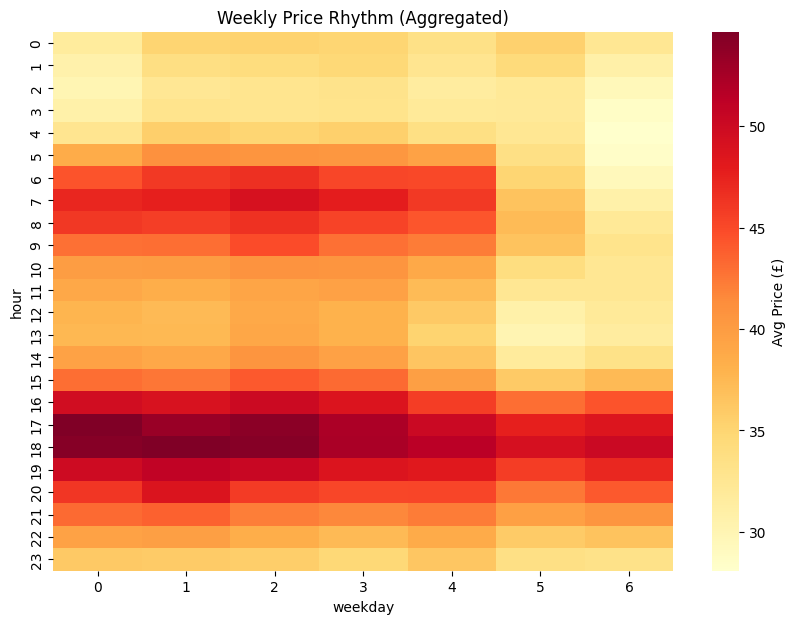

In [47]:
pivot_df = master_df.pivot_table(values='price', index='hour', columns='weekday', aggfunc='mean')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_df, cmap='YlOrRd', cbar_kws={'label': 'Avg Price (£)'})
plt.title('Weekly Price Rhythm (Aggregated)')
plt.show()

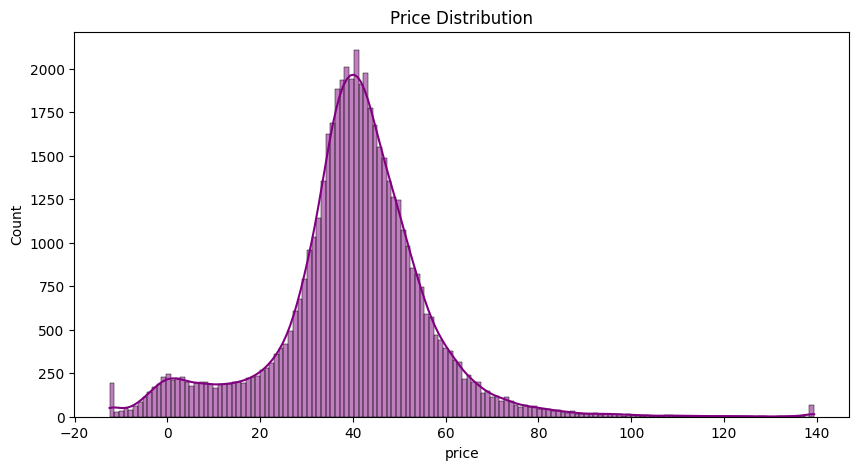

In [48]:
# Sample 10% of the data for a near-instant plot
# df_sample = master_df['price'].sample(frac=1, random_state=42)

plt.figure(figsize=(10, 5))
sns.histplot(master_df['price'], kde=True, color='purple', bins=150)
plt.title('Price Distribution')
plt.show()

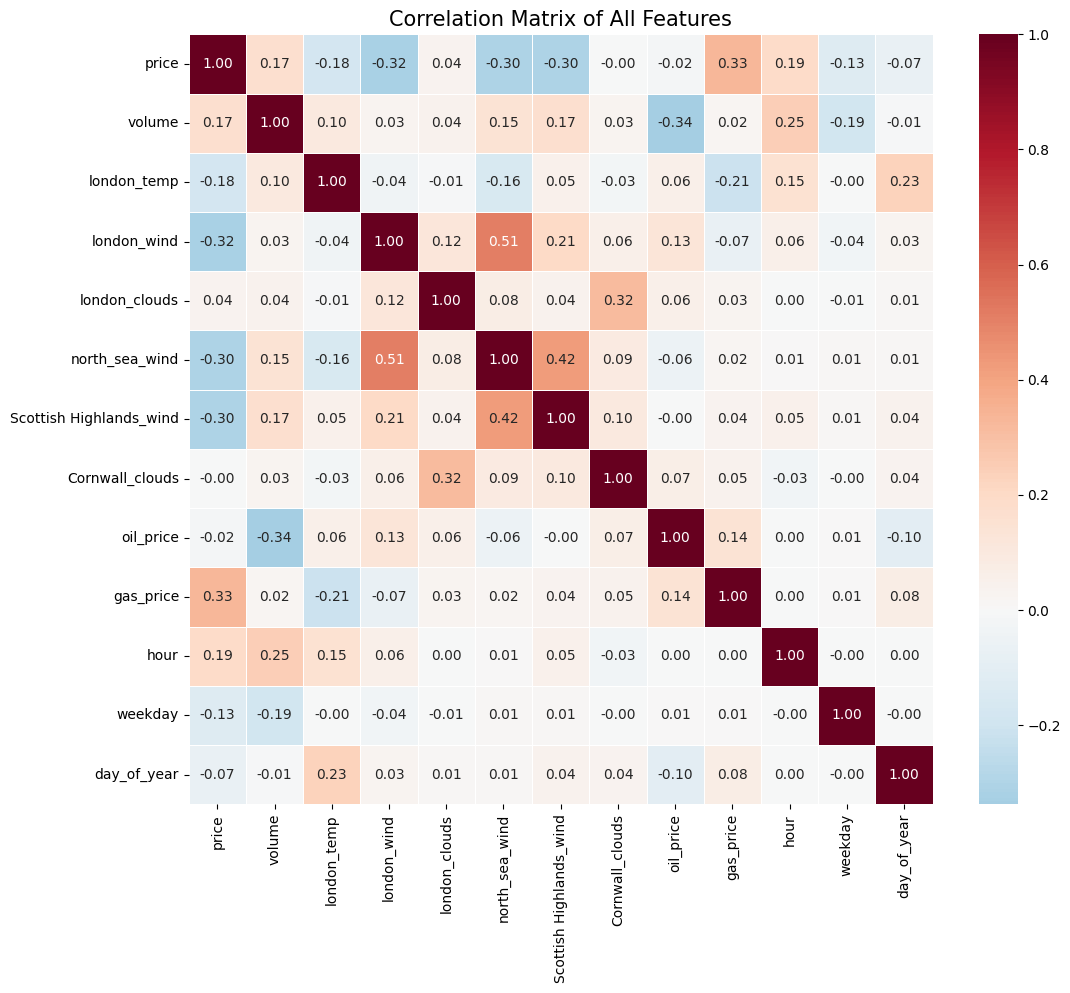

In [49]:
# Calculate the correlation matrix
corr_matrix = master_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of All Features', fontsize=15)
plt.show()

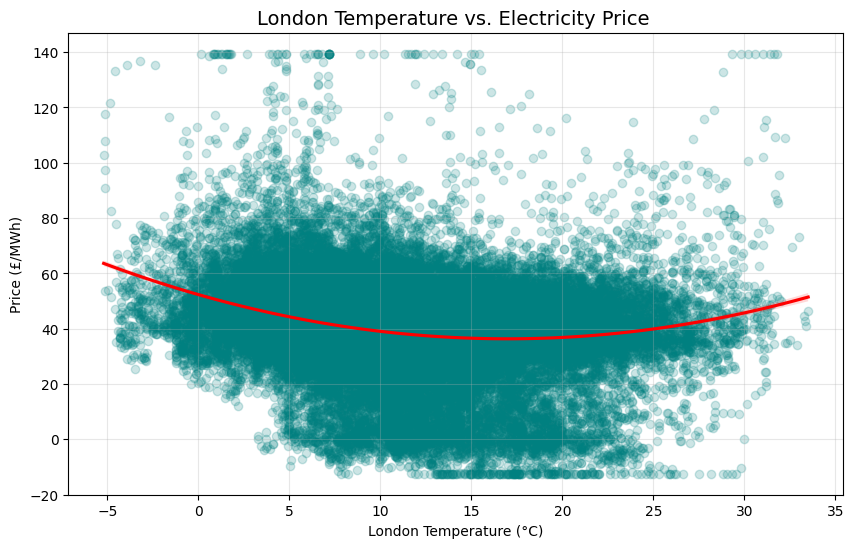

In [50]:
# df_sample = master_df.sample(frac=0.5, random_state=42)

plt.figure(figsize=(10, 6))
# 'order=2' fits a curve instead of a straight line to capture the U-shape
sns.regplot(data=master_df, x='london_temp', y='price', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, 
            line_kws={'color':'red'}, order=2)

plt.title('London Temperature vs. Electricity Price ', fontsize=14)
plt.xlabel('London Temperature (°C)')
plt.ylabel('Price (£/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

<Axes: ylabel='london_temp'>

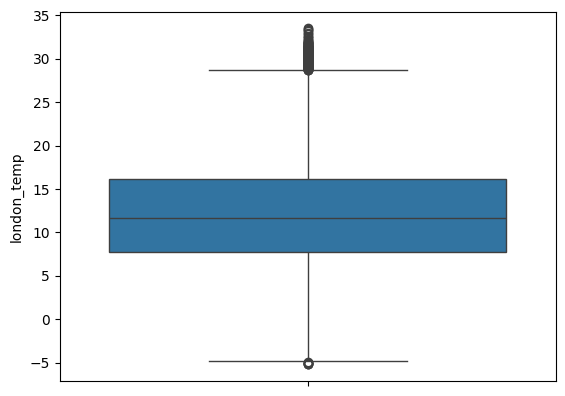

In [51]:
sns.boxplot(master_df['london_temp'])

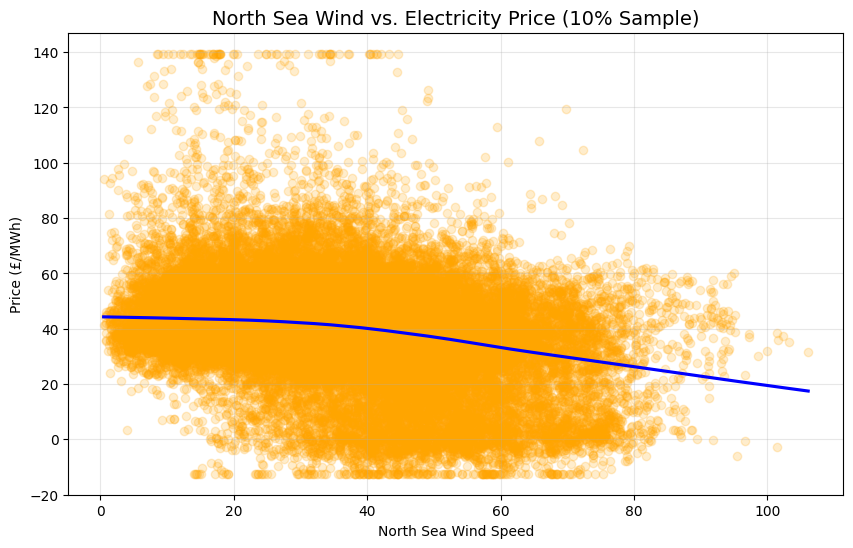

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(data=master_df, x='north_sea_wind', y='price', 
            scatter_kws={'alpha':0.2, 'color':'orange'}, 
            line_kws={'color':'blue'}, lowess=True)
# plt.ylim(-100,300)
plt.title('North Sea Wind vs. Electricity Price (10% Sample)', fontsize=14)
plt.xlabel('North Sea Wind Speed')
plt.ylabel('Price (£/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1200x500 with 0 Axes>

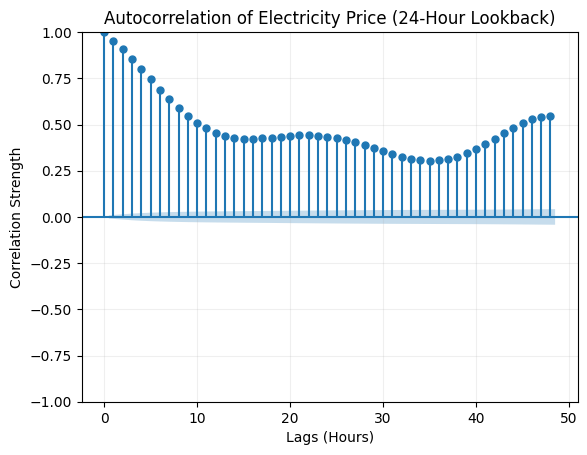

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))
plot_acf(master_df['price'], lags=48, alpha=0.05)

plt.title('Autocorrelation of Electricity Price (24-Hour Lookback)')
plt.xlabel('Lags (Hours)')
plt.ylabel('Correlation Strength')
plt.grid(True, alpha=0.2)
plt.show()

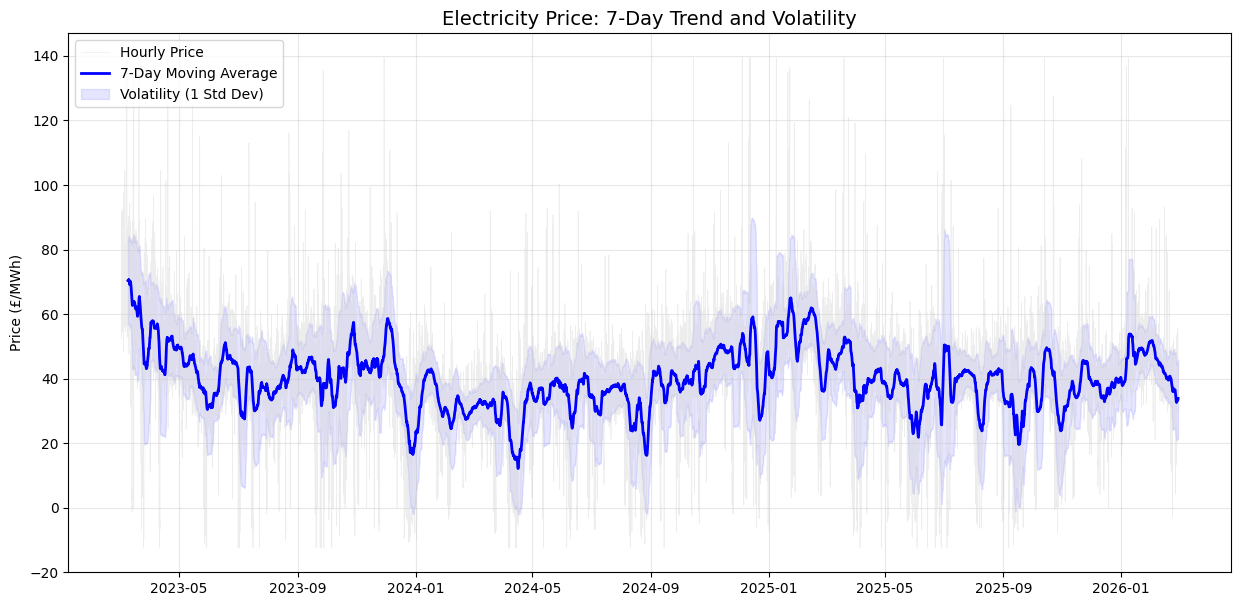

In [ ]:
# 24 hours * 7 days = 168 observations
rolling_mean = master_df['price'].rolling(window=48*7).mean()
rolling_std = master_df['price'].rolling(window=48*7).std()

plt.figure(figsize=(15, 7))

plt.plot(master_df.index, master_df['price'], color='lightgray', alpha=0.4, label='Hourly Price', linewidth=0.5)

plt.plot(rolling_mean.index, rolling_mean, color='blue', label='7-Day Moving Average', linewidth=2)

plt.fill_between(rolling_mean.index, 
                 rolling_mean - rolling_std, 
                 rolling_mean + rolling_std, 
                 color='blue', alpha=0.1, label='Volatility (1 Std Dev)')

plt.title('Electricity Price: 7-Day Trend and Volatility', fontsize=14)
plt.ylabel('Price (£/MWh)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

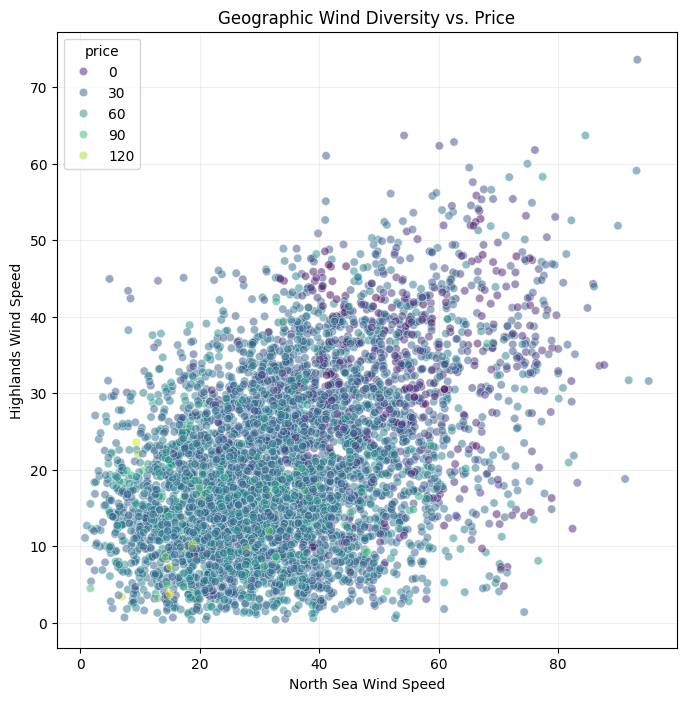

In [56]:
# Sample for speed
df_sample = master_df.sample(frac=0.1, random_state=42)

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_sample, x='north_sea_wind', y='Scottish Highlands_wind', 
                hue='price', palette='viridis', alpha=0.5)
plt.title('Geographic Wind Diversity vs. Price')
plt.xlabel('North Sea Wind Speed')
plt.ylabel('Highlands Wind Speed')
plt.grid(True, alpha=0.2)
plt.show()

C:\Users\steph\AppData\Local\Temp\ipykernel_30212\3991862563.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daytime_df['cloud_bins'] = pd.cut(daytime_df['Cornwall_clouds'], bins=5)
C:\Users\steph\AppData\Local\Temp\ipykernel_30212\3991862563.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daytime_df, x='cloud_bins', y='price', palette='Blues')


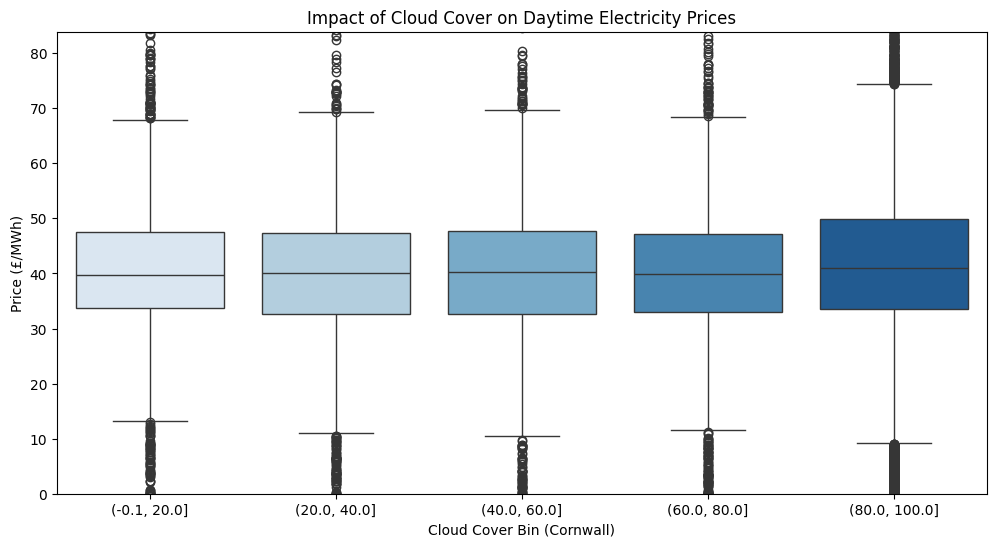

In [ ]:
# C'Daytime' filter so we don't look at clouds at night
daytime_df = master_df[(master_df['hour'] > 8) & (master_df['hour'] < 18)]

plt.figure(figsize=(12, 6))
daytime_df['cloud_bins'] = pd.cut(daytime_df['Cornwall_clouds'], bins=5)

sns.boxplot(data=daytime_df, x='cloud_bins', y='price', palette='Blues')
plt.title('Impact of Cloud Cover on Daytime Electricity Prices')
plt.xlabel('Cloud Cover Bin (Cornwall)')
plt.ylabel('Price (£/MWh)')
plt.ylim(0, master_df['price'].quantile(0.99)) 
plt.show()

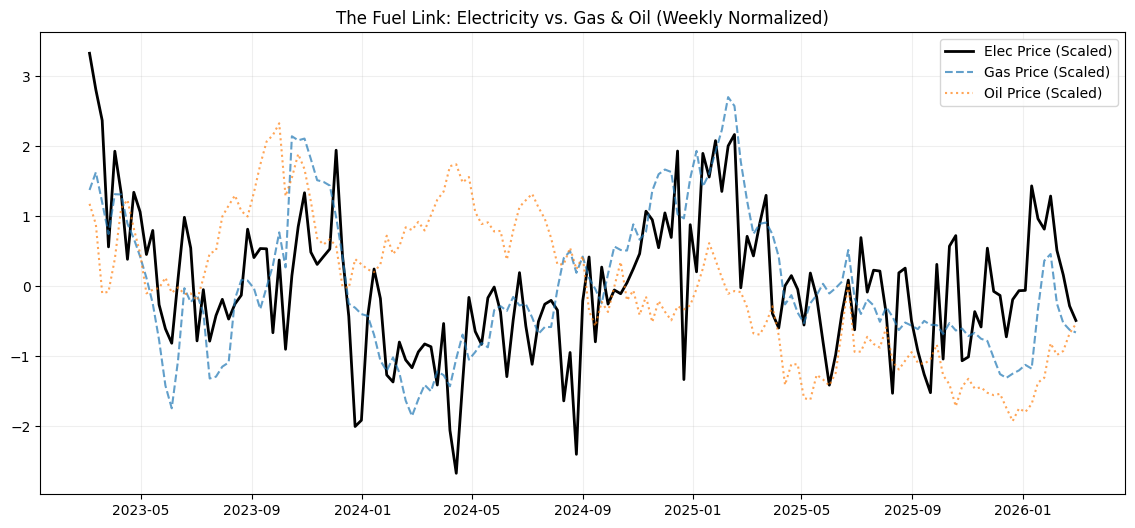

In [59]:
# Resample to weekly to see the long-term relationship clearly
df_weekly = master_df[['price', 'gas_price', 'oil_price']].resample('W').mean()

# Standardize (Scale) so they fit on the same Y-axis
df_scaled = (df_weekly - df_weekly.mean()) / df_weekly.std()

plt.figure(figsize=(14, 6))
plt.plot(df_scaled.index, df_scaled['price'], label='Elec Price (Scaled)', linewidth=2, color='black')
plt.plot(df_scaled.index, df_scaled['gas_price'], label='Gas Price (Scaled)', linestyle='--', alpha=0.7)
plt.plot(df_scaled.index, df_scaled['oil_price'], label='Oil Price (Scaled)', linestyle=':', alpha=0.7)

plt.title('The Fuel Link: Electricity vs. Gas & Oil (Weekly Normalized)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [63]:
master_df_1 = pd.read_csv('price_commo_2023_2026.csv', index_col=0)
master_df_2 = pd.read_csv('price_commo_avail_power_2023_2026.csv', index_col=0)
master_df_1.index = pd.to_datetime(master_df_1.index)
master_df_2.index = pd.to_datetime(master_df_2.index)

In [67]:
master_df_2

,price,volume,oil_price,gas_price,available_mw
time,,,,,
2022-03-04 00:00:00+00:00,282.900,954.30,118.110001,192.550003,1186370.0
2022-03-04 01:00:00+00:00,237.935,1309.10,118.110001,192.550003,1186370.0
2022-03-04 02:00:00+00:00,246.690,1706.45,118.110001,192.550003,1186370.0
2022-03-04 03:00:00+00:00,243.565,1024.55,118.110001,192.550003,1186370.0
2022-03-04 04:00:00+00:00,277.225,1249.30,118.110001,192.550003,1186370.0
...,...,...,...,...,...
2026-02-28 20:00:00+00:00,88.395,4753.00,72.480003,31.959000,1366534.0
2026-02-28 21:00:00+00:00,86.635,4357.40,72.480003,31.959000,1366534.0
2026-02-28 22:00:00+00:00,89.570,4884.35,72.480003,31.959000,1366534.0


In [66]:
master_df_1

,price,volume,london_temp,london_wind,london_clouds,north_sea_wind,Scottish Highlands_wind,Cornwall_clouds,oil_price,gas_price,hour,weekday,day_of_year
time,,,,,,,,,,,,,
2023-03-02 00:00:00+00:00,53.500,363.125,2.50,25.30,30.0,17.90,22.30,57.0,84.750000,46.814999,0,3,61
2023-03-02 00:30:00+00:00,59.365,367.825,1.95,24.50,15.0,17.20,21.55,47.5,84.750000,46.814999,0,3,61
2023-03-02 01:00:00+00:00,60.185,409.050,1.40,23.70,0.0,16.50,20.80,38.0,84.750000,46.814999,1,3,61
2023-03-02 01:30:00+00:00,56.985,394.550,1.15,24.10,0.5,15.70,19.50,30.0,84.750000,46.814999,1,3,61
2023-03-02 02:00:00+00:00,58.200,442.500,0.90,24.50,1.0,14.90,18.20,22.0,84.750000,46.814999,2,3,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 22:00:00+00:00,45.415,1165.700,6.00,22.00,84.0,26.70,22.20,100.0,72.480003,31.959000,22,5,59
2026-02-28 22:30:00+00:00,44.155,1276.475,6.15,21.80,77.5,28.65,21.00,100.0,72.480003,31.959000,22,5,59
2026-02-28 23:00:00+00:00,44.730,1303.550,6.30,21.60,71.0,30.60,19.80,100.0,72.480003,31.959000,23,5,59


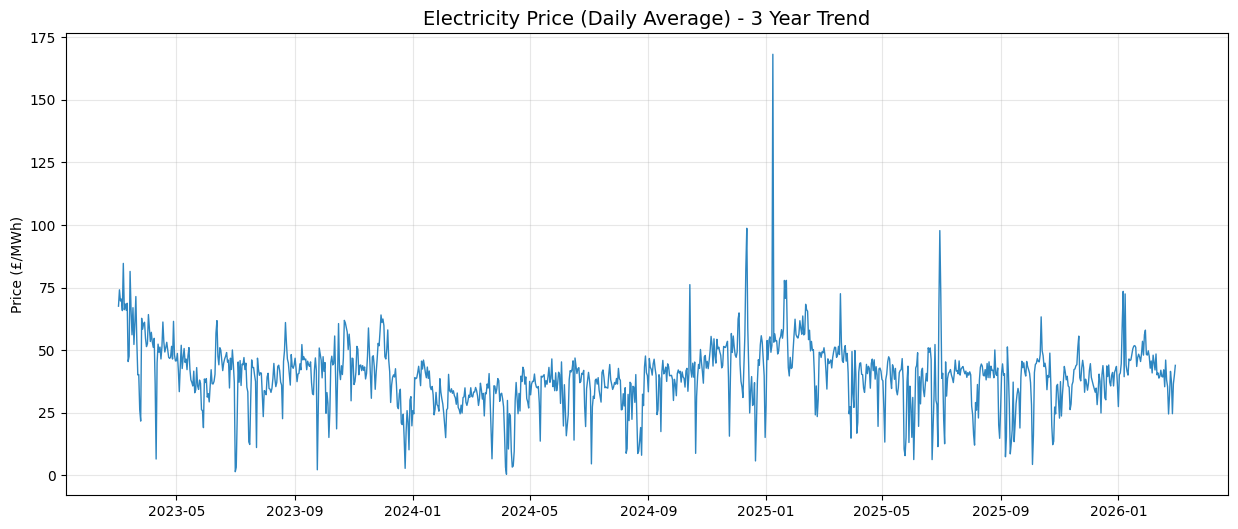

In [64]:
df_daily = master_df_1['price'].resample('D').mean()

plt.figure(figsize=(15, 6))
# Using a slightly thicker line since there are fewer points
plt.plot(df_daily.index, df_daily, color='#2E86C1', linewidth=1)

plt.title('Electricity Price (Daily Average) - 3 Year Trend', fontsize=14)
plt.ylabel('Price (£/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

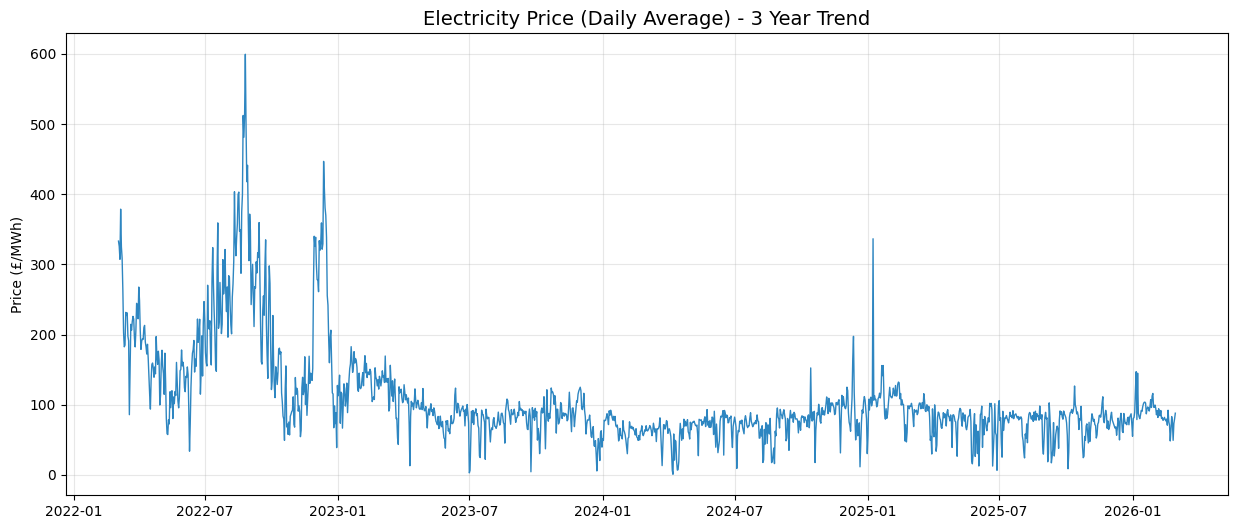

In [65]:
df_daily = master_df_2['price'].resample('D').mean()

plt.figure(figsize=(15, 6))
# Using a slightly thicker line since there are fewer points
plt.plot(df_daily.index, df_daily, color='#2E86C1', linewidth=1)

plt.title('Electricity Price (Daily Average) - 3 Year Trend', fontsize=14)
plt.ylabel('Price (£/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import pandas as pd 

In [28]:
fuel_gen_df = pd.read_csv('ActualAggregatedGenerationByType-2026-03-18T20_00_00.000Z-2026-03-25T20_00_00.000Z.csv', index_col=0)

In [5]:
fuel_gen_df

,PublishTime,StartTime,SettlementDate,SettlementPeriod,FuelType,Generation
Dataset,,,,,,
FUELHH,2026-03-25T19:00:00Z,2026-03-25T18:30:00Z,2026-03-25,38,BIOMASS,1295
FUELHH,2026-03-25T19:00:00Z,2026-03-25T18:30:00Z,2026-03-25,38,CCGT,5322
FUELHH,2026-03-25T19:00:00Z,2026-03-25T18:30:00Z,2026-03-25,38,COAL,0
FUELHH,2026-03-25T19:00:00Z,2026-03-25T18:30:00Z,2026-03-25,38,INTELEC,996
FUELHH,2026-03-25T19:00:00Z,2026-03-25T18:30:00Z,2026-03-25,38,INTEW,-70
...,...,...,...,...,...,...
FUELHH,2026-03-18T19:30:00Z,2026-03-18T19:00:00Z,2026-03-18,39,OCGT,15
FUELHH,2026-03-18T19:30:00Z,2026-03-18T19:00:00Z,2026-03-18,39,OIL,0
FUELHH,2026-03-18T19:30:00Z,2026-03-18T19:00:00Z,2026-03-18,39,OTHER,1092


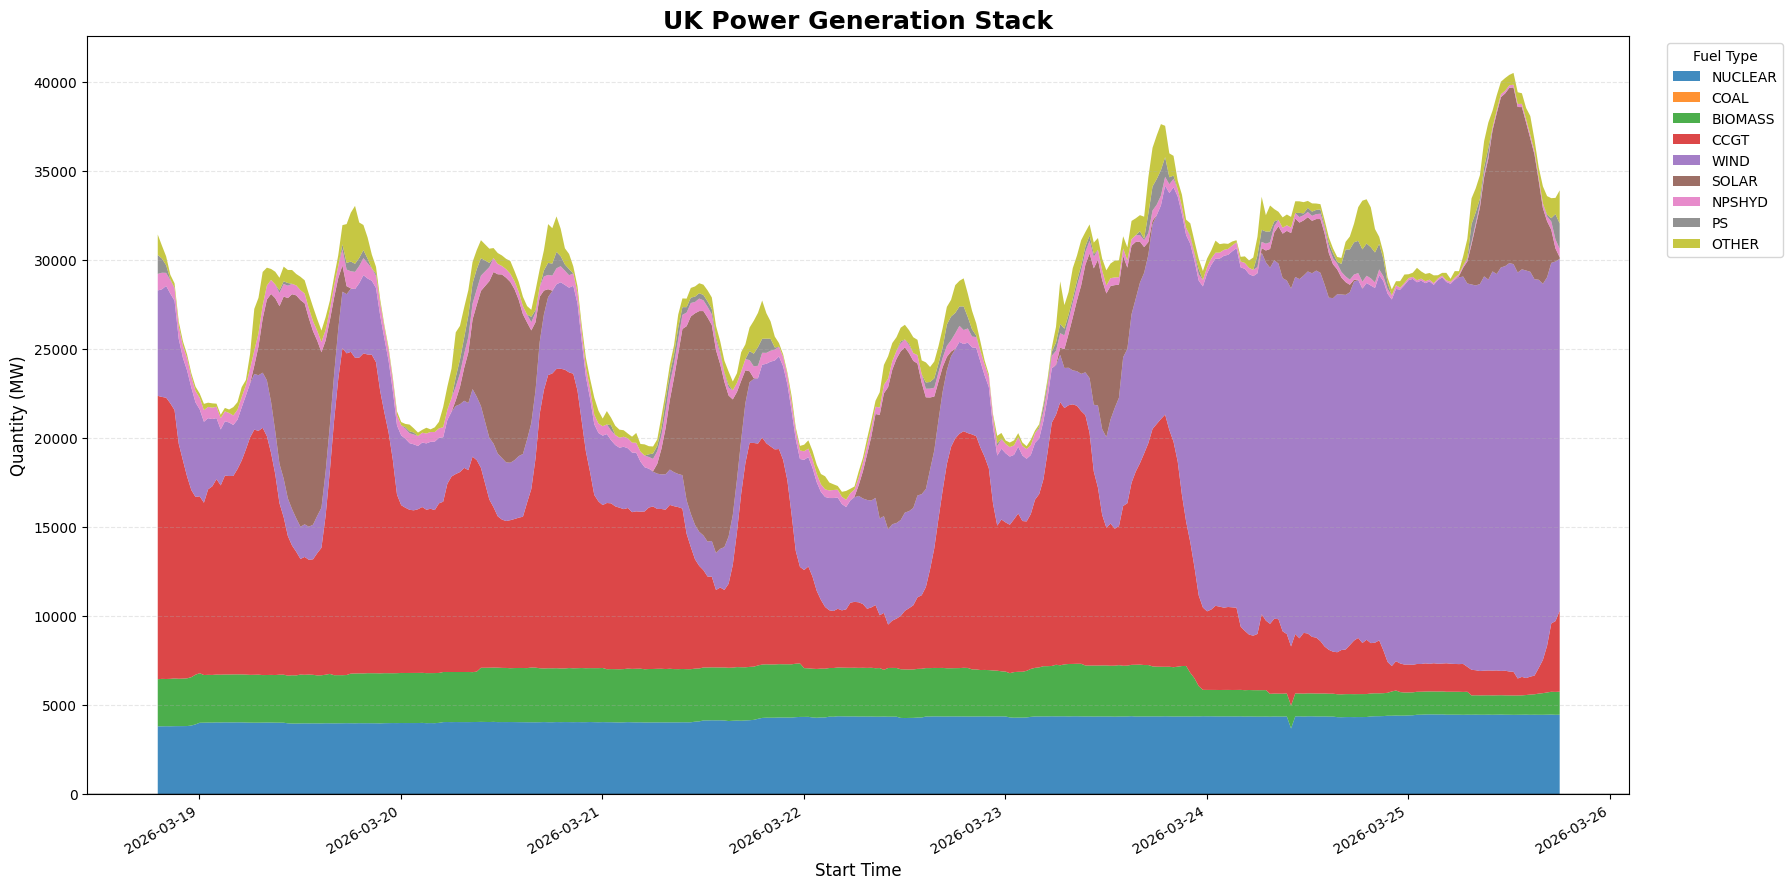

In [ ]:
mapping = {
    'Fossil Hard coal': 'COAL',
    'Fossil Gas': 'CCGT',
    'Fossil Oil': 'OIL',
    'Hydro Pumped Storage': 'PS',
    'Hydro Run-of-river and poundage': 'NPSHYD',
    'Wind Onshore': 'WIND',
    'Wind Offshore': 'WIND',
    'Solar': 'SOLAR',
    'Nuclear': 'NUCLEAR',
    'Biomass': 'BIOMASS',
    'Other': 'OTHER'
}

fuel_gen_df['FuelGroup'] = fuel_gen_df['PsrType'].map(mapping)

fuel_gen_df.loc[fuel_gen_df['PsrType'].str.contains('Interconnector|INT', case=False, na=False), 'FuelGroup'] = 'INTERCONNECTORS'


df_pivot = fuel_gen_df.pivot_table(
    index="StartTime",
    columns="FuelGroup",
    values="Quantity",
    aggfunc="sum"
).fillna(0)

df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot = df_pivot.sort_index()


# Nuclear -> Coal -> Biomass -> Interconnectors -> Rest
ordered_cols = [
    "NUCLEAR", "COAL", "BIOMASS", "INTERCONNECTORS", 
    "CCGT", "WIND", "SOLAR", "NPSHYD", "PS", "OTHER"
]
ordered_cols = [c for c in ordered_cols if c in df_pivot.columns]
df_pivot = df_pivot[ordered_cols]

# 5. Handle Positive/Negative (Imports/Exports)
df_pos = df_pivot.clip(lower=0)
df_neg = df_pivot.clip(upper=0)

# 6. Plotting
fig, ax = plt.subplots(figsize=(18, 9))

# Standard Energy Color Palette
# colors = {
#     "NUCLEAR": "#e85d04", "COAL": "#333533", "BIOMASS": "#007f5f", 
#     "INTERCONNECTORS": "#7b2cbf", "CCGT": "#ffba08", "WIND": "#48cae4", 
#     "SOLAR": "#f9c74f", "NPSHYD": "#0077b6", "PS": "#219ebc", "OTHER": "#adb5bd"
# }
# color_list = [colors.get(col, "#cccccc") for col in ordered_cols]

# Plot stacks
df_pos.plot(kind="area", stacked=True, ax=ax, alpha=0.85, linewidth=0)
if not df_neg.eq(0).all().all():
    df_neg.plot(kind="area", stacked=True, ax=ax, alpha=0.85, linewidth=0, legend=False)

# Formatting
plt.axhline(0, color='black', linewidth=1)
plt.title("UK Power Generation Stack", fontsize=18, fontweight='bold')
plt.ylabel("Quantity (MW)", fontsize=12)
plt.xlabel("Start Time", fontsize=12)
plt.legend(title="Fuel Type", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()